In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/deepanshus/StockMarketPredictor/Project/data/Combined/all/final_processed_data.csv")

df.head()

,rsi,macd,sma_ratio,volume_change,volatility,volatility_ratio,momentum,market_trend_bull,market_trend_neutral,target
0,0.076821,0.233960,0.759515,-0.080316,-0.459698,-0.480955,0.131378,-0.570778,0.871223,-0.009905
1,0.218344,0.243276,0.736068,-0.912631,-0.452419,-0.473299,0.155328,-0.570778,0.871223,0.033691
2,0.438078,0.310275,0.872104,-1.741018,-0.323617,-0.353315,0.248063,-0.570778,0.871223,-0.012892
3,0.001980,0.266755,0.882030,-0.306238,-0.291937,-0.323231,0.153981,-0.570778,0.871223,0.000297
4,-0.116686,0.228003,0.882452,-0.830791,-0.292183,-0.323480,0.105761,-0.570778,0.871223,-0.004599


In [3]:
print("Shape:", df.shape)

df.info()

df.describe(include='all')

Shape: (28637, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28637 entries, 0 to 28636
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rsi                   28637 non-null  float64
 1   macd                  28637 non-null  float64
 2   sma_ratio             28637 non-null  float64
 3   volume_change         28637 non-null  float64
 4   volatility            28637 non-null  float64
 5   volatility_ratio      28637 non-null  float64
 6   momentum              28637 non-null  float64
 7   market_trend_bull     28637 non-null  float64
 8   market_trend_neutral  28637 non-null  float64
 9   target                28637 non-null  float64
dtypes: float64(10)
memory usage: 2.2 MB


,rsi,macd,sma_ratio,volume_change,volatility,volatility_ratio,momentum,market_trend_bull,market_trend_neutral,target
count,2.863700e+04,28637.000000,2.863700e+04,2.863700e+04,2.863700e+04,2.863700e+04,2.863700e+04,2.863700e+04,2.863700e+04,28637.000000
mean,-1.806317e-16,0.000000,2.647446e-15,-1.240603e-17,1.587971e-16,-1.032181e-16,4.763914e-17,1.389475e-17,5.160907e-17,0.000124
std,1.000017e+00,1.000017,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,0.014310
min,-2.484649e+00,-2.773773,-2.841982e+00,-2.373321e+00,-1.002131e+00,-1.000656e+00,-3.913785e+00,-5.707776e-01,-1.147812e+00,-0.041268
25%,-6.086915e-01,-0.338301,-6.236764e-01,-6.814344e-01,-5.939173e-01,-5.931033e-01,-3.840465e-01,-5.707776e-01,-1.147812e+00,-0.007877
50%,1.979608e-03,-0.091644,1.074238e-02,-8.031605e-02,-3.276435e-01,-3.274839e-01,-1.906618e-01,-5.707776e-01,8.712230e-01,0.000446
75%,5.994394e-01,0.276540,5.830729e-01,5.114669e-01,-1.562156e-02,-1.710777e-02,1.850797e-01,-5.707776e-01,8.712230e-01,0.007563
max,2.637302e+00,3.281443,2.925907e+00,3.115101e+00,3.856036e+00,4.231371e+00,4.936334e+00,1.751996e+00,8.712230e-01,0.042690


In [4]:
df.dtypes

rsi                     float64
macd                    float64
sma_ratio               float64
volume_change           float64
volatility              float64
volatility_ratio        float64
momentum                float64
market_trend_bull       float64
market_trend_neutral    float64
target                  float64
dtype: object

rsi                     0
macd                    0
sma_ratio               0
volume_change           0
volatility              0
volatility_ratio        0
momentum                0
market_trend_bull       0
market_trend_neutral    0
target                  0
dtype: int64


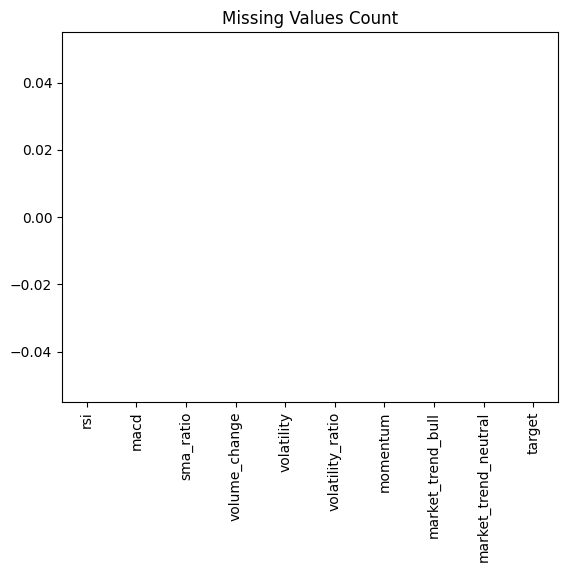

In [5]:
missing = df.isnull().sum()

print(missing)

missing.plot(kind='bar', title="Missing Values Count")
plt.show()

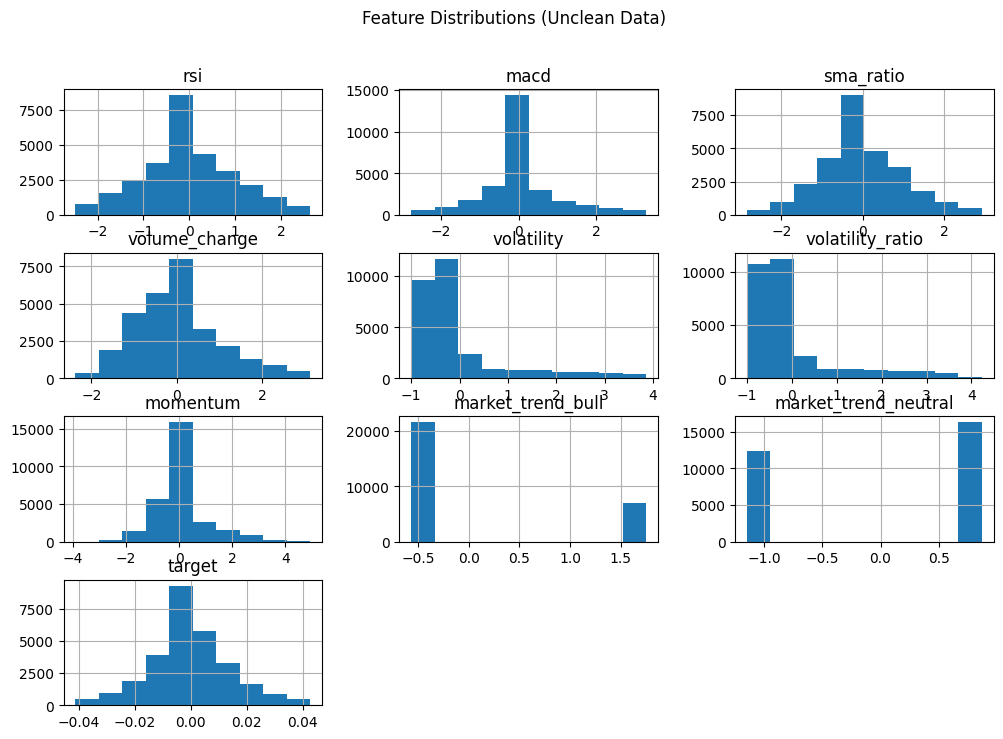

In [6]:
df.select_dtypes(include='number').hist(figsize=(12,8))
plt.suptitle("Feature Distributions (Unclean Data)")
plt.show()

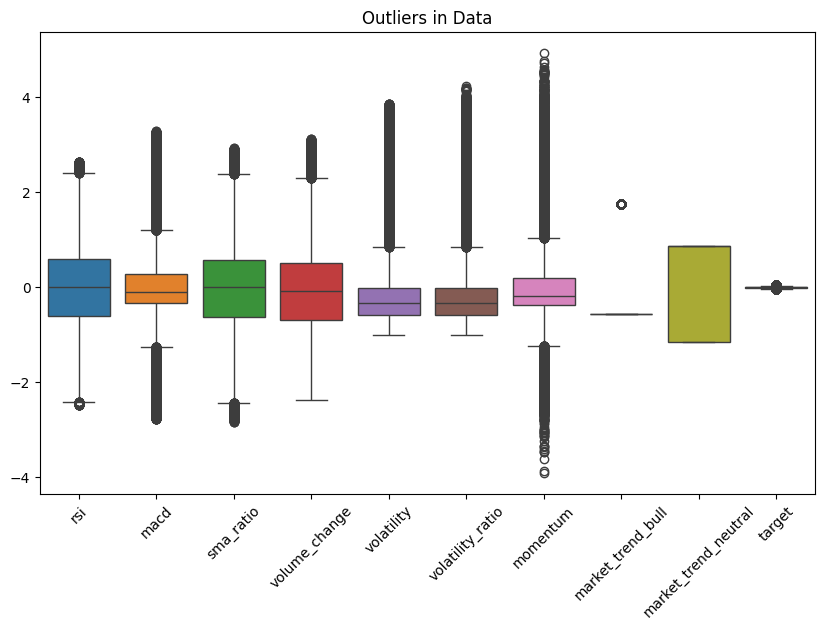

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.title("Outliers in Data")
plt.xticks(rotation=45)
plt.show()

In [8]:
for col in df.columns:
    print(f"{col} unique values:\n", df[col].unique()[:10], "\n")

rsi unique values:
 [ 0.07682099  0.21834447  0.43807756  0.00197961 -0.11668604  0.03345772
  0.42741226  0.78494669  0.72864868  0.85732574] 

macd unique values:
 [0.23395951 0.24327588 0.31027475 0.26675495 0.22800269 0.18251399
 0.1104392  0.07436284 0.10950469 0.14045739] 

sma_ratio unique values:
 [0.75951473 0.73606824 0.87210367 0.88202962 0.88245207 0.88479464
 0.84248672 0.75354794 0.72879582 0.72405306] 

volume_change unique values:
 [-0.08031605 -0.91263134 -1.74101782 -0.30623756 -0.83079109 -0.73788969
  0.47477838 -1.17455263 -0.11228434 -1.68760322] 

volatility unique values:
 [-0.45969752 -0.45241878 -0.32361683 -0.29193733 -0.29218272 -0.29068705
 -0.26578084 -0.38485229 -0.34392625 -0.35971805] 

volatility_ratio unique values:
 [-0.48095497 -0.47329923 -0.35331532 -0.32323098 -0.32348045 -0.32212288
 -0.29677729 -0.40858983 -0.3683291  -0.38343315] 

momentum unique values:
 [0.13137808 0.15532815 0.24806255 0.15398078 0.10576081 0.07579478
 0.01125762 0.0035699

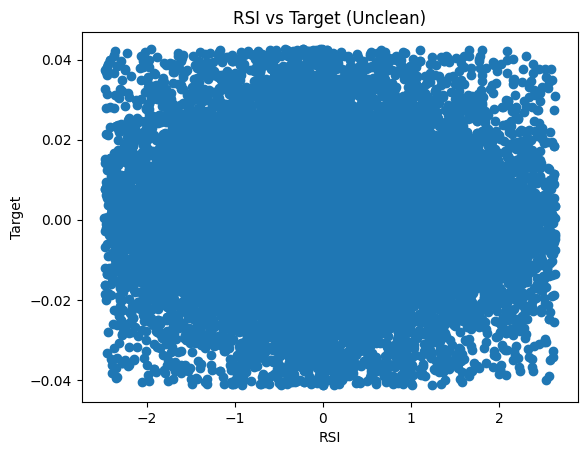

In [9]:
plt.scatter(pd.to_numeric(df["rsi"], errors='coerce'),
            pd.to_numeric(df["target"], errors='coerce'))

plt.xlabel("RSI")
plt.ylabel("Target")
plt.title("RSI vs Target (Unclean)")
plt.show()

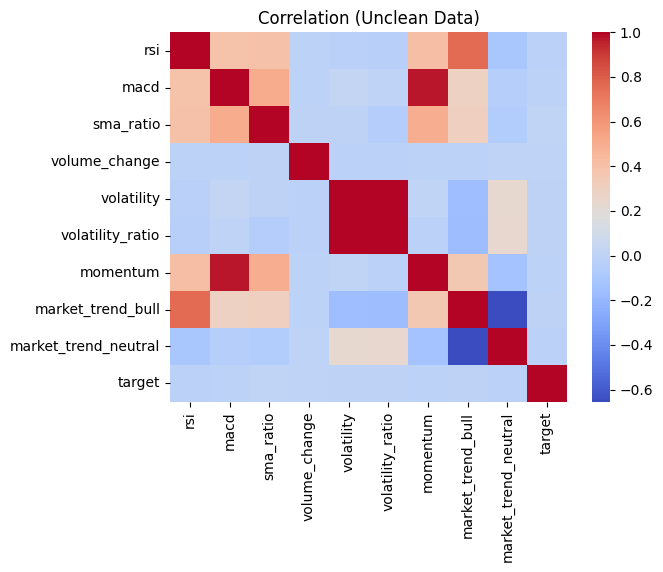

In [10]:
temp_df = df.apply(pd.to_numeric, errors='coerce')

sns.heatmap(temp_df.corr(), cmap="coolwarm")
plt.title("Correlation (Unclean Data)")
plt.show()

In [11]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [12]:
skewness = df.select_dtypes(include='number').skew()
print(skewness)

rsi                     0.089066
macd                    0.553100
sma_ratio               0.142224
volume_change           0.675969
volatility              2.075133
volatility_ratio        2.083239
momentum                1.194166
market_trend_bull       1.181280
market_trend_neutral   -0.276603
target                  0.064911
dtype: float64


In [13]:
kurt = df.select_dtypes(include='number').kurt()
print(kurt)

rsi                    -0.072094
macd                    1.533864
sma_ratio               0.242485
volume_change           0.382208
volatility              3.624905
volatility_ratio        3.686358
momentum                2.766225
market_trend_bull      -0.604619
market_trend_neutral   -1.923625
target                  0.579973
dtype: float64


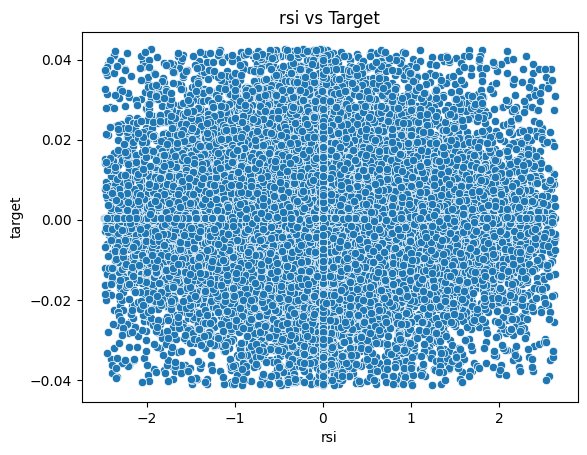

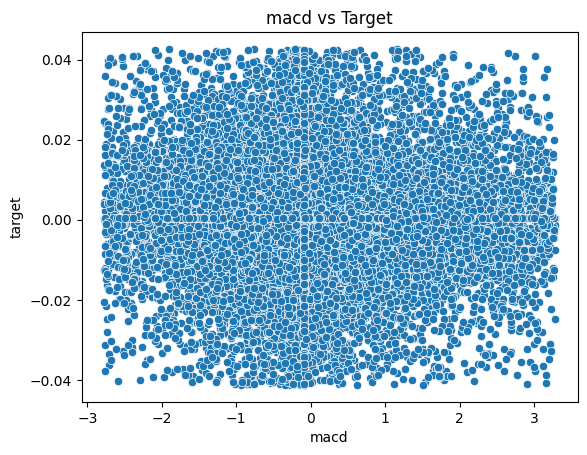

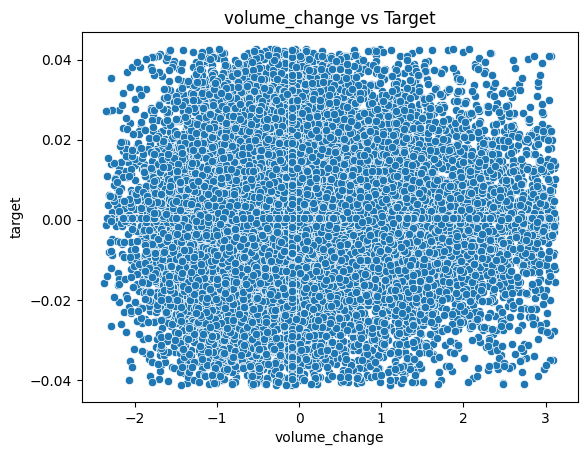

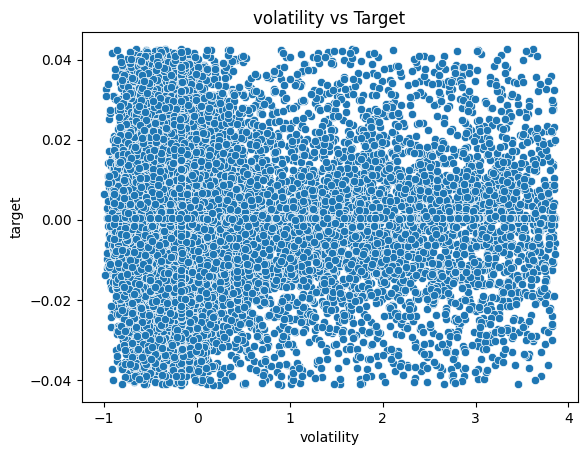

In [15]:
features = ["rsi", "macd", "volume_change", "volatility"]

for col in features:
    sns.scatterplot(x=pd.to_numeric(df[col], errors='coerce'),
                    y=pd.to_numeric(df["target"], errors='coerce'))
    plt.title(f"{col} vs Target")
    plt.show()

In [16]:
corr = temp_df.corr()["target"].sort_values(ascending=False)
print(corr)

target                  1.000000
sma_ratio               0.004877
volume_change           0.003952
market_trend_bull      -0.002337
volatility             -0.006026
volatility_ratio       -0.006950
momentum               -0.012530
macd                   -0.014616
market_trend_neutral   -0.017330
rsi                    -0.021354
Name: target, dtype: float64


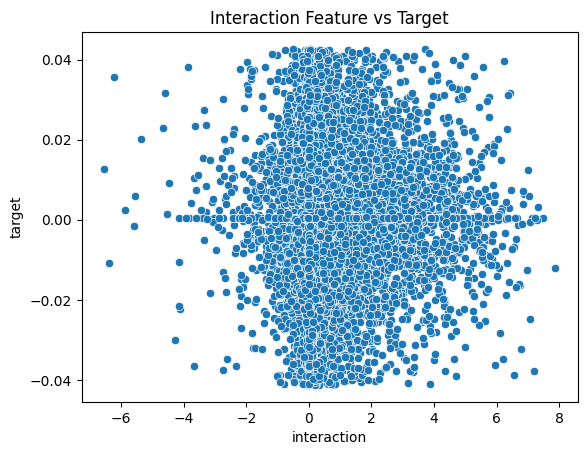

In [18]:
df["interaction"] = pd.to_numeric(df["rsi"], errors='coerce') * \
                    pd.to_numeric(df["macd"], errors='coerce')

sns.scatterplot(x=df["interaction"], y=pd.to_numeric(df["target"], errors='coerce'))
plt.title("Interaction Feature vs Target")
plt.show()

In [19]:
df["rsi_bin"] = pd.cut(pd.to_numeric(df["rsi"], errors='coerce'), bins=5)

grouped = df.groupby("rsi_bin")["target"].mean()
print(grouped)

rsi_bin
(-2.49, -1.46]     0.000932
(-1.46, -0.436]    0.000533
(-0.436, 0.589]   -0.000195
(0.589, 1.613]     0.000222
(1.613, 2.637]    -0.000304
Name: target, dtype: float64


/var/folders/g8/43rm_8rs5wbchfhhkxt_832c0000gn/T/ipykernel_43718/3688366455.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("rsi_bin")["target"].mean()


In [20]:
variance = temp_df.var().sort_values(ascending=False)
print(variance)

momentum                1.000035
rsi                     1.000035
macd                    1.000035
sma_ratio               1.000035
volume_change           1.000035
volatility              1.000035
volatility_ratio        1.000035
market_trend_bull       1.000035
market_trend_neutral    1.000035
target                  0.000205
dtype: float64
